# Prophet Model for Rat Sightings in Manhattan

When using the prophet model, we should be rather careful.

https://towardsdatascience.com/fixing-prophets-forecasting-issue-b473afe2cc70/

https://www.reddit.com/r/datascience/comments/12b43ww/is_prophet_really_good/

https://medium.com/geekculture/is-facebooks-prophet-the-time-series-messiah-or-just-a-very-naughty-boy-8b71b136bc8c

https://www.mdpi.com/2571-9394/3/3/40#:~:text=Our%20results%20indicate%20that%20ARIMA%20models%20and%20LSTM,and%20easy%20to%20use%2C%20but%20considerably%20less%20accurate


https://www.reddit.com/r/statistics/comments/jp7bnx/q_shortcomings_of_facebook_prophet_for_time/




There might be an argument here that prophet models / neural prophet might do better on the larger data set of rat inspections, but that seems contrary to our own goals here.


In [270]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [271]:
from prophet import Prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

## Prep Data for Prophet

In [272]:
df = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs.csv')
df['created_date'] = pd.to_datetime(df['created_date']) 
df = df[df['borough']=='MANHATTAN']
full_dates = pd.date_range('2020-01-01', '2025-12-31', freq='D')
full_index = pd.MultiIndex.from_product([['MANHATTAN'], full_dates], names=['borough', 'created_date'])
df = df.set_index(['borough', 'created_date']).reindex(full_index).fillna({'count': 0}).reset_index()
df['count'] = df['count'].astype(int)
df.drop(columns=['borough'], inplace=True)
df = df.rename(columns = {'created_date' : 'ds', 'count':'y'})

In [273]:
# df_save = df.copy() 

In [274]:
# # Uncomment to choose a cut_off date for training.

# cut_off_bs = '2025-12-01'
# df = df[df['ds']<= cut_off_bs]

In [275]:
from pandas.tseries.holiday import USFederalHolidayCalendar

# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-01", end="2025-12-31")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

# holidays = pd.concat((playoffs, superbowls))

holidays = federal_holidays

In [276]:
# #. Uncomment this to ge rid of outliers (days with >40) sightings.
# df.loc[df['y'] > 40,'y'] = None

19:11:52 - cmdstanpy - INFO - Chain [1] start processing
19:11:52 - cmdstanpy - INFO - Chain [1] done processing


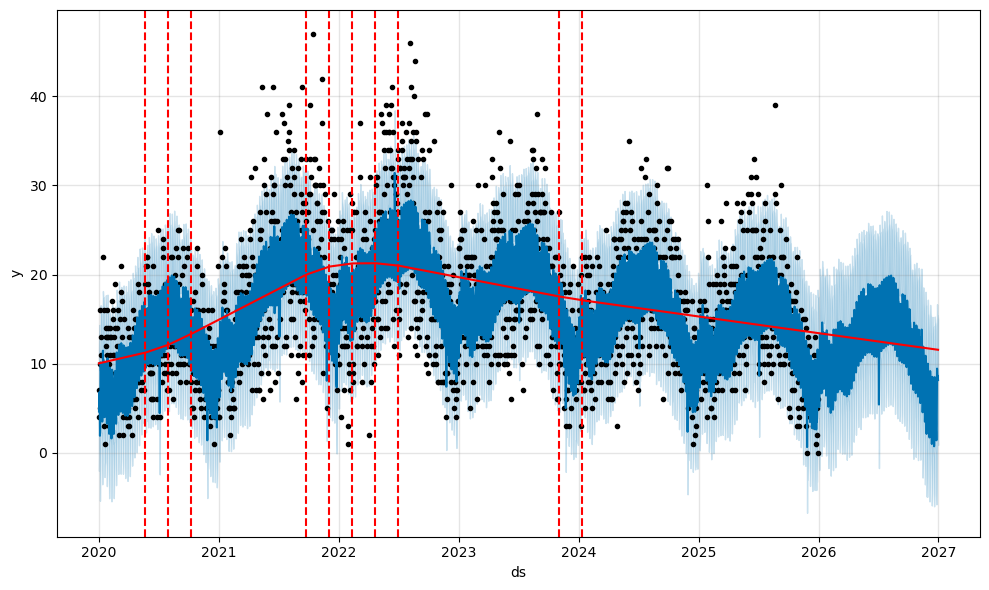

In [277]:
# changepoints = ['2024-11-12', '2025-01-02']
# yearly_seasonality=20
m = Prophet(holidays=holidays)
m.add_country_holidays(country_name='US')
m.fit(df)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
fig1 = m.plot(forecast)
a = add_changepoints_to_plot(fig1.gca(), m, forecast)

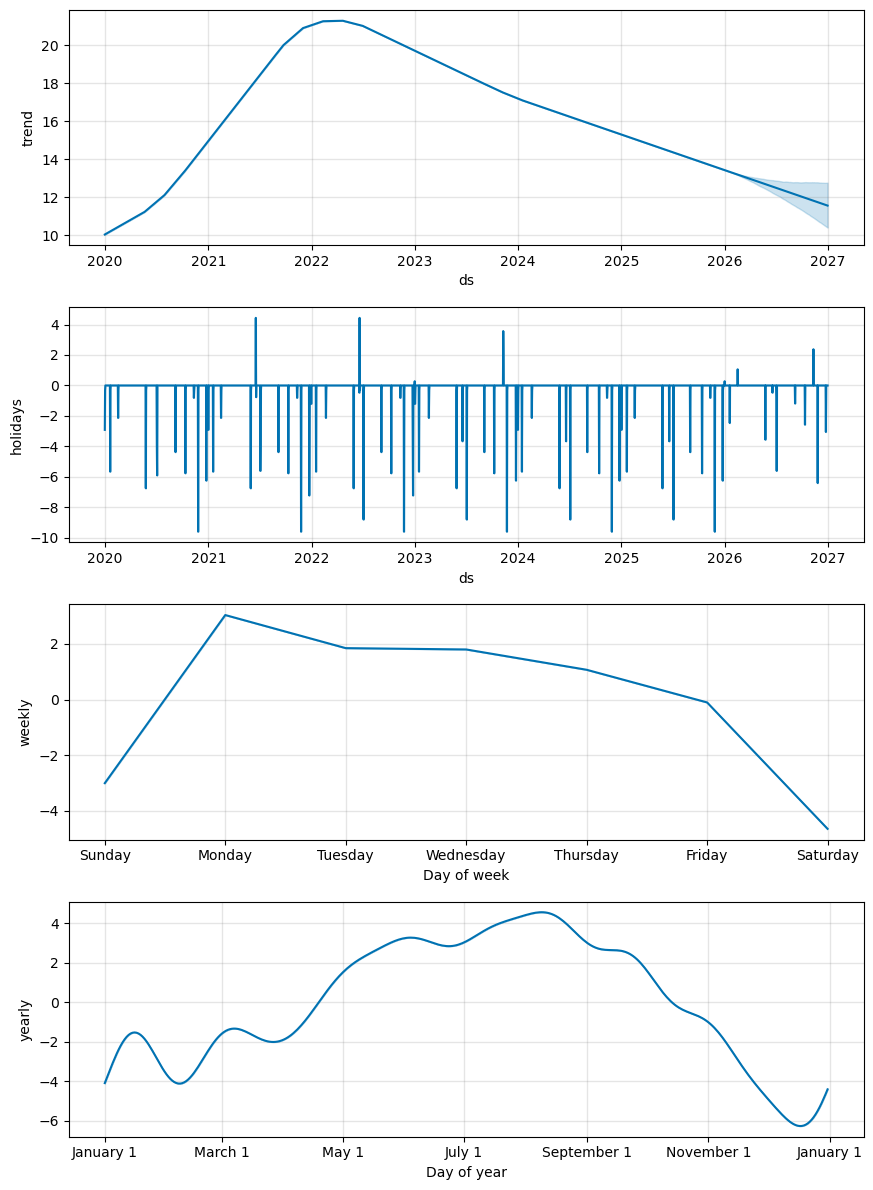

In [278]:
fig2 = m.plot_components(forecast)

In [279]:
m.train_holiday_names

0                                          federal_us
1                                      New Year's Day
2                                        Memorial Day
3                                    Independence Day
4                         Independence Day (observed)
5                                           Labor Day
6                                    Thanksgiving Day
7                                       Christmas Day
8                          Martin Luther King Jr. Day
9                               Washington's Birthday
10                                       Columbus Day
11                                       Veterans Day
12                          New Year's Day (observed)
13               Juneteenth National Independence Day
14    Juneteenth National Independence Day (observed)
15                           Christmas Day (observed)
16                            Veterans Day (observed)
dtype: str

## 80/20 Train Test Split

In [280]:
from sklearn.metrics import mean_squared_error

In [281]:
# Determine the split index
split_idx = int(len(df) * 0.8)  # 80% train, 20% test

df_train = df.iloc[:split_idx+1].copy()
df_test = df.iloc[split_idx+1:].copy()

m = Prophet(holidays=holidays)
m.add_country_holidays(country_name='US')
m.fit(df)
future = df_test[['ds']].copy()
forecast = m.predict(future)

rmse = np.sqrt(mean_squared_error(df_test['y'], forecast['yhat']))
print("Test RMSE:", rmse)

mae = np.mean(np.abs(df_test['y'] - forecast['yhat']))
print("Test MAE:", mae)

19:11:53 - cmdstanpy - INFO - Chain [1] start processing
19:11:54 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 4.774752728055302
Test MAE: nan


In [282]:
df_test

,ds,y
1754,2024-10-20,9
1755,2024-10-21,22
1756,2024-10-22,24
1757,2024-10-23,14
1758,2024-10-24,23
...,...,...
2187,2025-12-27,5
2188,2025-12-28,2
2189,2025-12-29,6
2190,2025-12-30,10


## Cross Validation

In [ ]:
regperiods = 30

cv_period = '30 days'

forecast_horizon = '7 days'

init_days = '730 days'

In [284]:
df_cv = cross_validation(m, 
                         initial=init_days, 
                         period=cv_period, 
                         horizon = forecast_horizon)

  0%|          | 0/49 [00:00<?, ?it/s]

19:11:54 - cmdstanpy - INFO - Chain [1] start processing
19:11:54 - cmdstanpy - INFO - Chain [1] done processing
19:11:54 - cmdstanpy - INFO - Chain [1] start processing
19:11:54 - cmdstanpy - INFO - Chain [1] done processing
19:11:54 - cmdstanpy - INFO - Chain [1] start processing
19:11:54 - cmdstanpy - INFO - Chain [1] done processing
19:11:55 - cmdstanpy - INFO - Chain [1] start processing
19:11:55 - cmdstanpy - INFO - Chain [1] done processing
19:11:55 - cmdstanpy - INFO - Chain [1] start processing
19:11:55 - cmdstanpy - INFO - Chain [1] done processing
19:11:55 - cmdstanpy - INFO - Chain [1] start processing
19:11:55 - cmdstanpy - INFO - Chain [1] done processing
19:11:55 - cmdstanpy - INFO - Chain [1] start processing
19:11:55 - cmdstanpy - INFO - Chain [1] done processing
19:11:55 - cmdstanpy - INFO - Chain [1] start processing
19:11:55 - cmdstanpy - INFO - Chain [1] done processing
19:11:56 - cmdstanpy - INFO - Chain [1] start processing
19:11:56 - cmdstanpy - INFO - Chain [1]

## Performance Metrics

In [285]:
df_p = performance_metrics(df_cv)
df_pbase = df_p

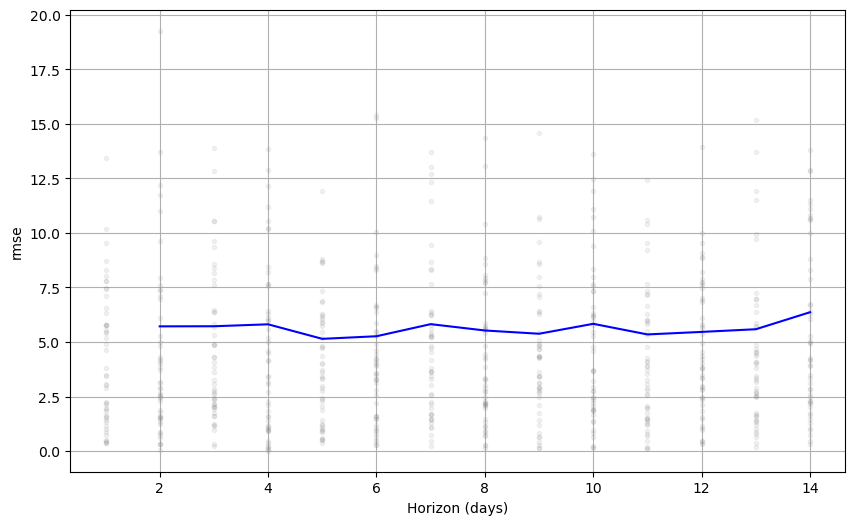

In [286]:
rolling_window=0.1
metric = 'rmse'
ax=None
figsize=(10, 6)
color='b'
point_color='gray'

fig = plt.figure(facecolor='w', figsize=figsize)
ax = fig.add_subplot(111)

fig = ax.get_figure()
# Get the metric at the level of individual predictions, and with the rolling window.
df_none = performance_metrics(df_cv, metrics=[metric], rolling_window=-1)
df_h = performance_metrics(df_cv, metrics=[metric], rolling_window=rolling_window)

# Some work because matplotlib does not handle timedelta
# Target ~10 ticks.
tick_w = max(df_none['horizon'].astype('timedelta64[ns]')) / 10.
# Find the largest time resolution that has <1 unit per bin.
dts = ['D', 'h', 'm', 's', 'ms', 'us', 'ns']
dt_names = [
    'days', 'hours', 'minutes', 'seconds', 'milliseconds', 'microseconds',
    'nanoseconds'
]
dt_conversions = [
    24 * 60 * 60 * 10 ** 9,
    60 * 60 * 10 ** 9,
    60 * 10 ** 9,
    10 ** 9,
    10 ** 6,
    10 ** 3,
    1.,
]
for i, dt in enumerate(dts):
    if np.timedelta64(1, dt) < np.timedelta64(tick_w, 'ns'):
        break

# x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
# x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])

x_plt = df_none['horizon'].astype('timedelta64[ns]').to_numpy().view(np.int64) / float(dt_conversions[i])
x_plt_h = df_h['horizon'].astype('timedelta64[ns]').to_numpy().view(np.int64) / float(dt_conversions[i])

ax.plot(x_plt, df_none[metric], '.', alpha=0.1, c=point_color)
ax.plot(x_plt_h, df_h[metric], '-', c=color)
ax.grid(True)

ax.set_xlabel('Horizon ({})'.format(dt_names[i]))
ax.set_ylabel(metric)

plt.show()

In [287]:
# ## baseline compare

# future = m.make_future_dataframe(periods=365)
# forecast = m.predict(future)
# forecast
# fore = forecast[forecast['ds'] >= cut_off_bs]
# fore = fore[fore['ds'] <= '2025-12-31']

# df_save = df_save[df_save['ds'] >= cut_off_bs]
# df_save = df_save[df_save['ds'] <= '2025-12-31']

# rmse_base = np.sqrt(np.mean((fore['yhat'] - df_save['y']) ** 2))
# rmse_base

## Initial Rat Inspections as Additional Regressor

In [288]:
path = r'../scr/data/cleaned_rat_inspection_data' 
all_files = glob.glob(os.path.join(path , "*.csv"))
df2 = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
df2 = df2[df2['inspection_type']=='Initial']
df2['inspection_date'] = pd.to_datetime(df2['inspection_date']) 
df2 = df2[df2['borough']=='Manhattan']
df2= df2[['inspection_date', 'result']].copy()

In [289]:
pp = df2.copy()
pp.rename(columns={'inspection_date': 'date', 'result':'y'}, inplace=True)
pp = pp[pp['date'] >= '2020-01-01']
pp = pp[pp['date'] <='2025-12-31']

pp = pp.copy()
pp["date"] = pd.to_datetime(pp["date"])
pp["ds"] = pp["date"].dt.date
pp = (
    pp.groupby("ds")
      .agg(
          total_entries=("y", "size"),
          non_passed=("y", lambda s: (s != "Passed").sum())
      )
      .assign(pct_non_passed=lambda d: d["non_passed"] / d["total_entries"] * 100)
      .reset_index()
      .sort_values("ds")
)

In [290]:
# Ensure 'ds' column is datetime
pp['ds'] = pd.to_datetime(pp['ds'])

# Create full date range
full_dates = pd.date_range(start='2020-01-01', end='2025-12-31')

# Reindex the DataFrame to include all dates
pp = pp.set_index('ds').reindex(full_dates, fill_value=0).rename_axis('ds').reset_index()

pp = pp[['ds', 'total_entries', 'non_passed', 'pct_non_passed']]

In [291]:
df['total_inspect'] = pp['total_entries']
df['non_passed'] = pp['non_passed']
df['pct_non_passed'] = pp['pct_non_passed']

df['total_inspect'] = df['total_inspect'].fillna(0)
df['non_passed'] = df['non_passed'].fillna(0)
df['pct_non_passed'] = df['pct_non_passed'].fillna(0)

In [292]:
# We will need to forecast the regressors so that we can use these forecasts for predictions

def forecast_regressor(df_reg, periods=30):
    """
    df_reg: DataFrame with columns ['ds', 'y'] for one regressor
    periods: number of days to forecast
    """
    m = Prophet()
    m.fit(df_reg)
    
    future = m.make_future_dataframe(periods=periods)
    forecast = m.predict(future)
    
    # Return only the 'yhat' forecast column
    return forecast[['ds', 'yhat']]

# total_inspect
df_total_inspect = df[['ds', 'total_inspect']].rename(columns={'total_inspect': 'y'})
forecast_total_inspect = forecast_regressor(df_total_inspect, periods=regperiods)
forecast_total_inspect.rename(columns={'yhat': 'total_inspect'}, inplace=True)

# non_passed
df_non_passed = df[['ds', 'non_passed']].rename(columns={'non_passed': 'y'})
forecast_non_passed = forecast_regressor(df_non_passed, periods=regperiods)
forecast_non_passed.rename(columns={'yhat': 'non_passed'}, inplace=True)

# pct_non_passed
df_pct_non_passed = df[['ds', 'pct_non_passed']].rename(columns={'pct_non_passed': 'y'})
forecast_pct_non_passed = forecast_regressor(df_pct_non_passed, periods=regperiods)
forecast_pct_non_passed.rename(columns={'yhat': 'pct_non_passed'}, inplace=True)

# Build dataframe for the future.
future = df[['ds']].copy()  # only historical rows

19:12:17 - cmdstanpy - INFO - Chain [1] start processing
19:12:17 - cmdstanpy - INFO - Chain [1] done processing
19:12:17 - cmdstanpy - INFO - Chain [1] start processing
19:12:17 - cmdstanpy - INFO - Chain [1] done processing
19:12:17 - cmdstanpy - INFO - Chain [1] start processing
19:12:17 - cmdstanpy - INFO - Chain [1] done processing


In [293]:
# Create the future dates
future_dates = pd.DataFrame({'ds': pd.date_range(start=df['ds'].max() + pd.Timedelta(days=1), periods=regperiods, freq='D')})

# Combine historical + future dates
future = pd.concat([future, future_dates], ignore_index=True)


# Add forecasts for inspections, nonpassed, nonpassing rates. 
future = future.merge(forecast_total_inspect, on='ds', how='left')
future = future.merge(forecast_non_passed, on='ds', how='left')
future = future.merge(forecast_pct_non_passed, on='ds', how='left')


# Fill old rows with correct values
future.loc[future['ds'] <= df['ds'].max(), 'total_inspect'] = df['total_inspect'].values
future.loc[future['ds'] <= df['ds'].max(), 'non_passed'] = df['non_passed'].values
future.loc[future['ds'] <= df['ds'].max(), 'pct_non_passed'] = df['pct_non_passed'].values

19:12:18 - cmdstanpy - INFO - Chain [1] start processing
19:12:18 - cmdstanpy - INFO - Chain [1] done processing


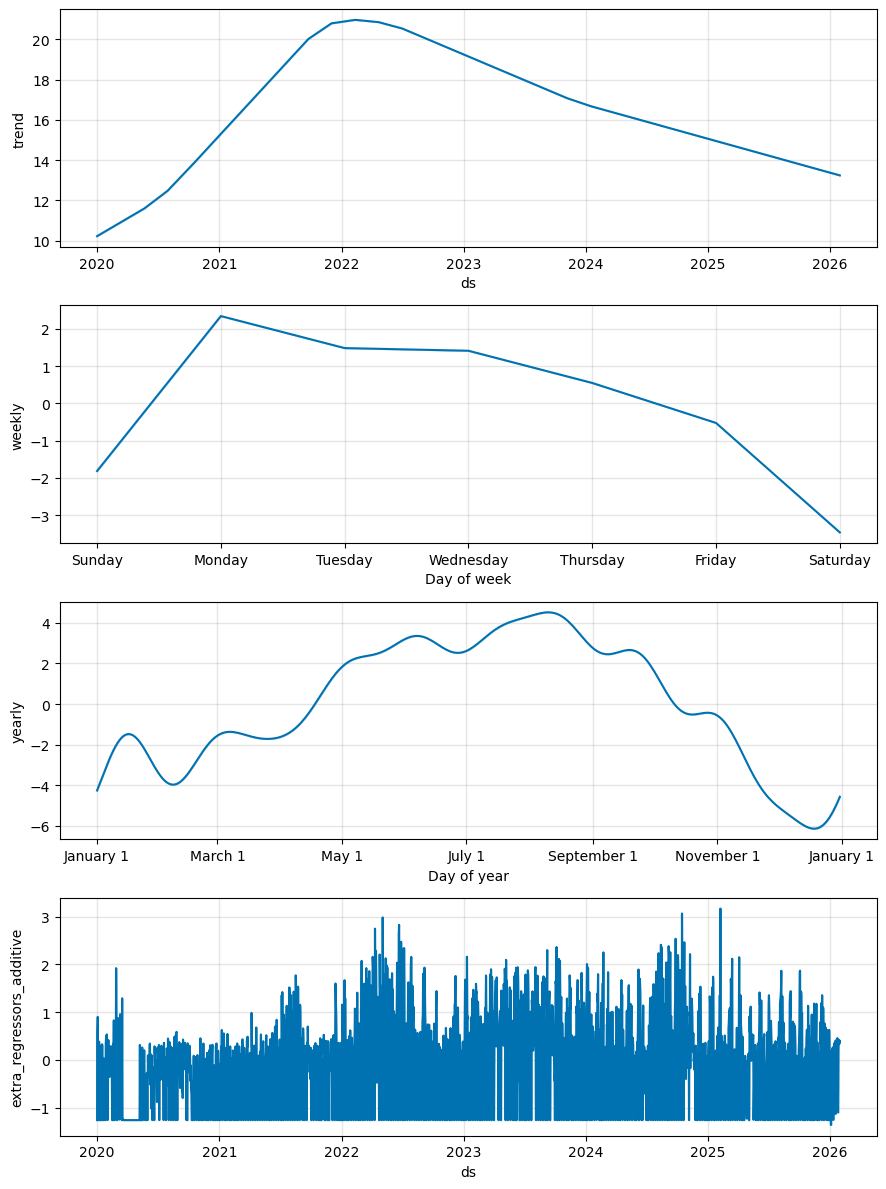

In [294]:
# Forecasting with the regressors
m_main = Prophet()
m_main.add_regressor('total_inspect')
m_main.add_regressor('non_passed')
m_main.add_regressor('pct_non_passed')

m_main.fit(df)  # df has historical regressors

forecast_main = m_main.predict(future)

fig = m_main.plot_components(forecast_main)

In [295]:
# Cross-validation: starts with initial number of days, testing periods are given, and we forecast by horizon
df_cv = cross_validation(m_main, initial=init_days, period=cv_period, horizon=forecast_horizon)
df_p = performance_metrics(df_cv)
df_pri = df_p

  0%|          | 0/49 [00:00<?, ?it/s]

19:12:19 - cmdstanpy - INFO - Chain [1] start processing
19:12:19 - cmdstanpy - INFO - Chain [1] done processing
19:12:19 - cmdstanpy - INFO - Chain [1] start processing
19:12:19 - cmdstanpy - INFO - Chain [1] done processing
19:12:19 - cmdstanpy - INFO - Chain [1] start processing
19:12:19 - cmdstanpy - INFO - Chain [1] done processing
19:12:19 - cmdstanpy - INFO - Chain [1] start processing
19:12:19 - cmdstanpy - INFO - Chain [1] done processing
19:12:19 - cmdstanpy - INFO - Chain [1] start processing
19:12:19 - cmdstanpy - INFO - Chain [1] done processing
19:12:19 - cmdstanpy - INFO - Chain [1] start processing
19:12:19 - cmdstanpy - INFO - Chain [1] done processing
19:12:20 - cmdstanpy - INFO - Chain [1] start processing
19:12:20 - cmdstanpy - INFO - Chain [1] done processing
19:12:20 - cmdstanpy - INFO - Chain [1] start processing
19:12:20 - cmdstanpy - INFO - Chain [1] done processing
19:12:20 - cmdstanpy - INFO - Chain [1] start processing
19:12:20 - cmdstanpy - INFO - Chain [1]

In [296]:
df_pbase


,horizon,mse,rmse,mae,mdape,smape,coverage
0,2 days,32.699590,5.718356,4.314039,0.216479,0.256824,0.790216
1,3 days,32.754585,5.723162,4.521047,0.235584,0.268660,0.781212
2,4 days,33.778423,5.811921,4.512585,0.236168,0.262122,0.760804
3,5 days,26.483908,5.146252,4.132443,0.218116,0.258400,0.843337
4,6 days,27.724109,5.265369,4.172599,0.202181,0.268864,0.848139
5,7 days,33.867401,5.819571,4.675453,0.208648,0.268112,0.807323
6,8 days,30.572442,5.529235,4.402987,0.195637,0.278223,0.781212
7,9 days,28.944590,5.380018,4.373379,0.226303,0.273057,0.804922
8,10 days,34.047113,5.834990,4.738925,0.294259,0.309894,0.772209
9,11 days,28.603353,5.348210,4.287819,0.218470,0.273932,0.828631


In [297]:
df_pri

,horizon,mse,rmse,mae,mdape,smape,coverage
0,2 days,33.978745,5.829129,4.369882,0.216139,0.261501,0.825330
1,3 days,34.634026,5.885068,4.667425,0.231554,0.279963,0.792617
2,4 days,32.910794,5.736793,4.556325,0.199824,0.266375,0.760804
3,5 days,28.191330,5.309551,4.327278,0.245786,0.269227,0.828631
4,6 days,30.935170,5.561939,4.379897,0.196938,0.270362,0.827731
5,7 days,36.136740,6.011384,4.720753,0.217541,0.268315,0.801621
6,8 days,32.934010,5.738816,4.545061,0.229451,0.292926,0.795918
7,9 days,29.834672,5.462112,4.425728,0.236692,0.279892,0.795918
8,10 days,34.847358,5.903165,4.735467,0.290547,0.302897,0.737095
9,11 days,29.384389,5.420737,4.405783,0.225690,0.275583,0.817227


In [298]:
df_compare = pd.DataFrame({
    "horizon": df_pbase["horizon"],
    # Error metrics: True if df_pbase <= df_pri
    "mse":    df_pbase["mse"]    <= df_pri["mse"],
    "rmse":   df_pbase["rmse"]   <= df_pri["rmse"],
    "mae":    df_pbase["mae"]    <= df_pri["mae"],
    "mdape":  df_pbase["mdape"]  <= df_pri["mdape"],
    # Coverage columns copied as is
    "df_pbase_coverage": df_pbase["coverage"],
    "df_pri_coverage":   df_pri["coverage"],
})

df_compare

,horizon,mse,rmse,mae,mdape,df_pbase_coverage,df_pri_coverage
0,2 days,True,True,True,False,0.790216,0.825330
1,3 days,True,True,True,False,0.781212,0.792617
2,4 days,False,False,True,False,0.760804,0.760804
3,5 days,True,True,True,True,0.843337,0.828631
4,6 days,True,True,True,False,0.848139,0.827731
5,7 days,True,True,True,True,0.807323,0.801621
6,8 days,True,True,True,True,0.781212,0.795918
7,9 days,True,True,True,True,0.804922,0.795918
8,10 days,True,True,False,False,0.772209,0.737095
9,11 days,True,True,True,True,0.828631,0.817227


## Conclusions

1. Including the rat inspection data does not seem to provide any improvement in modeling the forecasting of rat sightings (whether it be weekly forecasting, daily forecasting, etc.). I think this is because the additional regressors are more or less "linear" regressors so due to seasonality of rat inspections, the influence is not going to improve the model.

## Comparison to Holt Winters Models

In [299]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet.diagnostics import performance_metrics

# ensure sorted
df = df.sort_values("ds").reset_index(drop=True)

cutoffs = df_cv["cutoff"].unique()
horizon = pd.Timedelta(forecast_horizon)

cv_rows = []

for cutoff in cutoffs:
    train = df[df["ds"] <= cutoff]
    test = df[(df["ds"] > cutoff) & (df["ds"] <= cutoff + horizon)]

    if len(test) == 0:
        continue

    # Fit ExponentialSmoothing
    model = ExponentialSmoothing(train["y"], trend="add", seasonal='add', seasonal_periods=365,).fit(optimized=True)

    # Forecast
    yhat = model.forecast(len(test))

    fold_df = pd.DataFrame({
        "ds": test["ds"].values,
        "y": test["y"].values,
        "yhat": yhat.values,
        "cutoff": cutoff
    })

    cv_rows.append(fold_df)

# Prophet-style CV dataframe
df_cv_es = pd.concat(cv_rows, ignore_index=True)
df_p_hw = performance_metrics(df_cv_es)
df_p_hw

,horizon,mse,rmse,mae,mdape,smape
0,2 days,61.087940,7.815877,6.123586,0.311507,0.355426
1,3 days,57.054114,7.553417,5.967385,0.302684,0.349026
2,4 days,60.373087,7.770012,6.225205,0.310761,0.372487
3,5 days,47.766515,6.911332,5.590317,0.306671,0.351871
4,6 days,49.872234,7.062028,5.538277,0.298066,0.354896
5,7 days,55.709239,7.463862,5.920804,0.290334,0.359425
6,8 days,57.629420,7.591404,6.124362,0.332125,0.373712
7,9 days,51.764216,7.194735,5.735658,0.320449,0.344664
8,10 days,50.437889,7.101964,5.436298,0.257408,0.337939
9,11 days,38.992445,6.244393,4.940263,0.253157,0.314550


In [300]:
## Compariing Prophet versus Holt-Winters

display(df_pbase)

display(df_p_hw)

,horizon,mse,rmse,mae,mdape,smape,coverage
0,2 days,32.699590,5.718356,4.314039,0.216479,0.256824,0.790216
1,3 days,32.754585,5.723162,4.521047,0.235584,0.268660,0.781212
2,4 days,33.778423,5.811921,4.512585,0.236168,0.262122,0.760804
3,5 days,26.483908,5.146252,4.132443,0.218116,0.258400,0.843337
4,6 days,27.724109,5.265369,4.172599,0.202181,0.268864,0.848139
5,7 days,33.867401,5.819571,4.675453,0.208648,0.268112,0.807323
6,8 days,30.572442,5.529235,4.402987,0.195637,0.278223,0.781212
7,9 days,28.944590,5.380018,4.373379,0.226303,0.273057,0.804922
8,10 days,34.047113,5.834990,4.738925,0.294259,0.309894,0.772209
9,11 days,28.603353,5.348210,4.287819,0.218470,0.273932,0.828631


,horizon,mse,rmse,mae,mdape,smape
0,2 days,61.087940,7.815877,6.123586,0.311507,0.355426
1,3 days,57.054114,7.553417,5.967385,0.302684,0.349026
2,4 days,60.373087,7.770012,6.225205,0.310761,0.372487
3,5 days,47.766515,6.911332,5.590317,0.306671,0.351871
4,6 days,49.872234,7.062028,5.538277,0.298066,0.354896
5,7 days,55.709239,7.463862,5.920804,0.290334,0.359425
6,8 days,57.629420,7.591404,6.124362,0.332125,0.373712
7,9 days,51.764216,7.194735,5.735658,0.320449,0.344664
8,10 days,50.437889,7.101964,5.436298,0.257408,0.337939
9,11 days,38.992445,6.244393,4.940263,0.253157,0.314550


In [301]:
df_result2 = pd.DataFrame({
    "horizon": df_pbase["horizon"],

    # Error metrics: True if df_pbase <= df_pri
    "mse":    df_pbase["mse"]    <= df_p_hw["mse"],
    "rmse":   df_pbase["rmse"]   <= df_p_hw["rmse"],
    "mae":    df_pbase["mae"]    <= df_p_hw["mae"],
    "mdape":  df_pbase["mdape"]  <= df_p_hw["mdape"],

    # Coverage columns copied directly
    "df_pbase_coverage": df_pbase["coverage"],
})

df_result2

,horizon,mse,rmse,mae,mdape,df_pbase_coverage
0,2 days,True,True,True,True,0.790216
1,3 days,True,True,True,True,0.781212
2,4 days,True,True,True,True,0.760804
3,5 days,True,True,True,True,0.843337
4,6 days,True,True,True,True,0.848139
5,7 days,True,True,True,True,0.807323
6,8 days,True,True,True,True,0.781212
7,9 days,True,True,True,True,0.804922
8,10 days,True,True,True,False,0.772209
9,11 days,True,True,True,True,0.828631


## Some hyperparameter tuning

In [302]:
import itertools

In [303]:
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
    'seasonality_prior_scale': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(df)  # Fit model with given params
    df_cv = cross_validation(m, horizon='365 days')
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses

best_params = all_params[np.argmin(rmses)]

print(best_params)

19:12:51 - cmdstanpy - INFO - Chain [1] start processing
19:12:51 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

19:12:51 - cmdstanpy - INFO - Chain [1] start processing
19:12:51 - cmdstanpy - INFO - Chain [1] done processing
19:12:51 - cmdstanpy - INFO - Chain [1] start processing
19:12:52 - cmdstanpy - INFO - Chain [1] done processing
19:12:52 - cmdstanpy - INFO - Chain [1] start processing
19:12:52 - cmdstanpy - INFO - Chain [1] done processing
19:12:52 - cmdstanpy - INFO - Chain [1] start processing
19:12:52 - cmdstanpy - INFO - Chain [1] done processing
19:12:52 - cmdstanpy - INFO - Chain [1] start processing
19:12:52 - cmdstanpy - INFO - Chain [1] done processing
19:12:52 - cmdstanpy - INFO - Chain [1] start processing
19:12:53 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

19:12:53 - cmdstanpy - INFO - Chain [1] start processing
19:12:53 - cmdstanpy - INFO - Chain [1] done processing
19:12:53 - cmdstanpy - INFO - Chain [1] start processing
19:12:53 - cmdstanpy - INFO - Chain [1] done processing
19:12:53 - cmdstanpy - INFO - Chain [1] start processing
19:12:53 - cmdstanpy - INFO - Chain [1] done processing
19:12:53 - cmdstanpy - INFO - Chain [1] start processing
19:12:53 - cmdstanpy - INFO - Chain [1] done processing
19:12:54 - cmdstanpy - INFO - Chain [1] start processing
19:12:54 - cmdstanpy - INFO - Chain [1] done processing
19:12:54 - cmdstanpy - INFO - Chain [1] start processing
19:12:54 - cmdstanpy - INFO - Chain [1] done processing


...

  0%|          | 0/5 [00:00<?, ?it/s]

19:14:02 - cmdstanpy - INFO - Chain [1] start processing
19:14:02 - cmdstanpy - INFO - Chain [1] done processing
19:14:02 - cmdstanpy - INFO - Chain [1] start processing
19:14:02 - cmdstanpy - INFO - Chain [1] done processing
19:14:02 - cmdstanpy - INFO - Chain [1] start processing
19:14:03 - cmdstanpy - INFO - Chain [1] done processing
19:14:03 - cmdstanpy - INFO - Chain [1] start processing
19:14:03 - cmdstanpy - INFO - Chain [1] done processing
19:14:04 - cmdstanpy - INFO - Chain [1] start processing
19:14:04 - cmdstanpy - INFO - Chain [1] done processing
19:14:04 - cmdstanpy - INFO - Chain [1] start processing
19:14:04 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/5 [00:00<?, ?it/s]

19:14:05 - cmdstanpy - INFO - Chain [1] start processing
19:14:05 - cmdstanpy - INFO - Chain [1] done processing
19:14:05 - cmdstanpy - INFO - Chain [1] start processing
19:14:05 - cmdstanpy - INFO - Chain [1] done processing
19:14:05 - cmdstanpy - INFO - Chain [1] start processing
19:14:06 - cmdstanpy - INFO - Chain [1] done processing
19:14:06 - cmdstanpy - INFO - Chain [1] start processing
19:14:06 - cmdstanpy - INFO - Chain [1] done processing
19:14:06 - cmdstanpy - INFO - Chain [1] start processing
19:14:07 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}


## 80 /20 Train Test Split with Better Parameters

In [304]:
# Determine the split index
split_idx = int(len(df) * 0.8)  # 80% train, 20% test

df_train = df.iloc[:split_idx+1].copy()
df_test = df.iloc[split_idx+1:].copy()
m = Prophet(holidays=holidays, changepoint_prior_scale=0.1, seasonality_prior_scale= 10.0)
m.add_country_holidays(country_name='US')
m.fit(df)
future = df_test[['ds']].copy()
forecast = m.predict(future)

rmse = np.sqrt(mean_squared_error(df_test['y'], forecast['yhat']))
print("Test RMSE:", rmse)

mae = np.mean(np.abs(df_test['y'] - forecast['yhat']))
print("Test MAE:", mae)

19:14:07 - cmdstanpy - INFO - Chain [1] start processing
19:14:07 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 4.7432045790768385
Test MAE: nan
